# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


### Perkenalan Dataset

Dataset yang digunakan pada project ini adalah Stroke Risk Dataset yang diperoleh dari Kaggle.

Sumber dataset: Kaggle – Stroke Risk Dataset  
https://www.kaggle.com/datasets/ranaghulamnabi/stroke-risk-dataset  

Dataset ini berisi data kesehatan pasien yang digunakan untuk menganalisis dan memprediksi risiko stroke. Data tersebut mencakup informasi terkait kondisi individu seperti karakteristik demografis, riwayat kesehatan, serta faktor-faktor yang berkaitan dengan gaya hidup.

Dataset ini digunakan dalam bidang machine learning, khususnya untuk tugas klasifikasi, serta dapat dimanfaatkan untuk eksplorasi data guna memahami pola yang berhubungan dengan risiko stroke. Tujuan utamanya adalah membantu proses identifikasi dini terhadap risiko stroke melalui pendekatan berbasis data.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
#Type your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
#Type your code here
df = pd.read_csv('healthcare-dataset-stroke-data.csv')

print("Shape:", df.shape)
print(df.head())

Shape: (5110, 12)
      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1  


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.


=== Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB

=== Deskripsi ===
                 id          age  hypertension  heart_disease  \
count   5110.000000  5110.000000   5110.000000    5110.0000

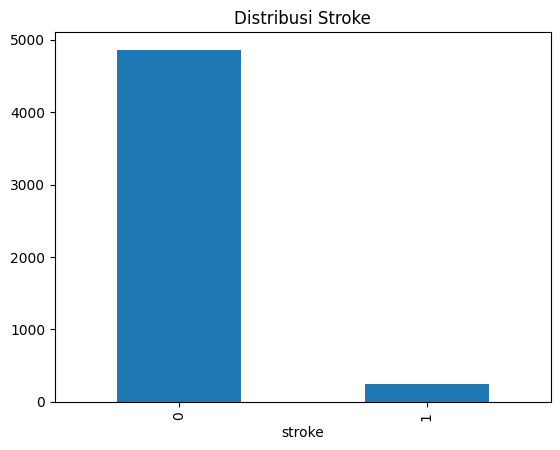

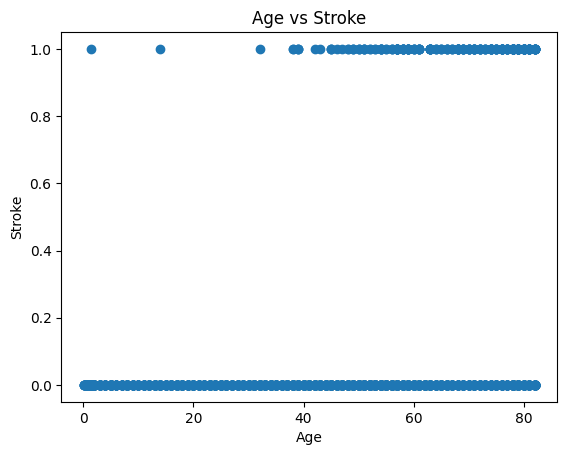

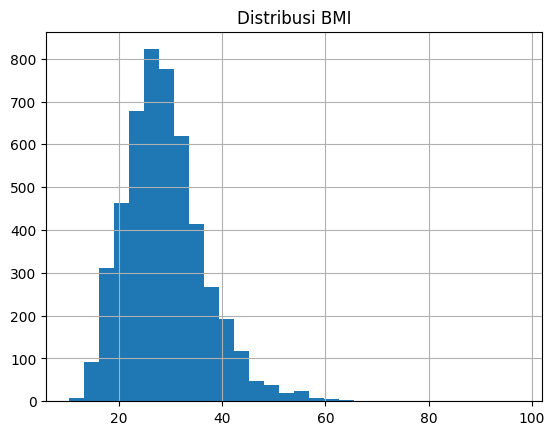

In [3]:
print("\n=== Info ===")
df.info()

print("\n=== Deskripsi ===")
print(df.describe())

print("\n=== Missing value ===")
print(df.isnull().sum())

print("\n=== Ddistribusi target ===")
print(df['stroke'].value_counts())

# Visualisasi
df['stroke'].value_counts().plot(kind='bar')
plt.title('Distribusi Stroke')
plt.show()

plt.scatter(df['age'], df['stroke'])
plt.title('Age vs Stroke')
plt.xlabel('Age')
plt.ylabel('Stroke')
plt.show()

df['bmi'].hist(bins=30)
plt.title('Distribusi BMI')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:
# Handle missing value
df['bmi'] = df['bmi'].fillna(df['bmi'].mean())

# Drop kolom tidak penting
df.drop(['id'], axis=1, inplace=True)

# Split fitur dan target
X = df.drop('stroke', axis=1)
y = df['stroke']

# Encoding (One Hot Encoding)
X = pd.get_dummies(X, drop_first=True)

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split train test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (4088, 16)
Test : (1022, 16)


Simpan hasil

In [5]:
os.makedirs("namadataset_preprocessing", exist_ok=True)

joblib.dump(X_train, "namadataset_preprocessing/X_train.joblib")
joblib.dump(X_test, "namadataset_preprocessing/X_test.joblib")
joblib.dump(y_train, "namadataset_preprocessing/y_train.joblib")
joblib.dump(y_test, "namadataset_preprocessing/y_test.joblib")
joblib.dump(scaler, "namadataset_preprocessing/scaler.joblib")

print("✅ Preprocessing selesai & disimpan")

✅ Preprocessing selesai & disimpan
